In [13]:
import os
from pathlib import Path
import sys

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
    sys.path.insert(0, os.getcwd())

PROJECT_ROOT = Path.cwd()

In [14]:
DATA_DIR = PROJECT_ROOT / "data"
BEATMAPS_DIR = DATA_DIR / "beatmaps"
COLLECTIONS_DIR = DATA_DIR / "collections"

RATINGS_PATH = DATA_DIR / "ratings.parquet"
BEATMAPS_PATH = BEATMAPS_DIR / "beatmaps.parquet"
COLLECTIONS_PATH = COLLECTIONS_DIR / "collections.parquet"

Loaded 97,236 beatmaps (< 14 stars)

STAR RATING STATISTICS
Mean:    5.42
Median:  5.51
Std Dev: 1.82
Range:   0.14 - 13.96

DISTRIBUTION
0-1     :     120 (  0.1%)
1-2     :   3,274 (  3.4%)
2-3     :   8,537 (  8.8%)
3-4     :   9,404 (  9.7%)
4-5     :  14,619 ( 15.0%)
5-6     :  24,534 ( 25.2%)
6-7     :  18,882 ( 19.4%)
7-8     :  10,906 ( 11.2%)
8-9     :   4,721 (  4.9%)
9-10    :   1,698 (  1.7%)
10-11   :     383 (  0.4%)
11-12   :     100 (  0.1%)
12-13   :      41 (  0.0%)
13-14   :      17 (  0.0%)


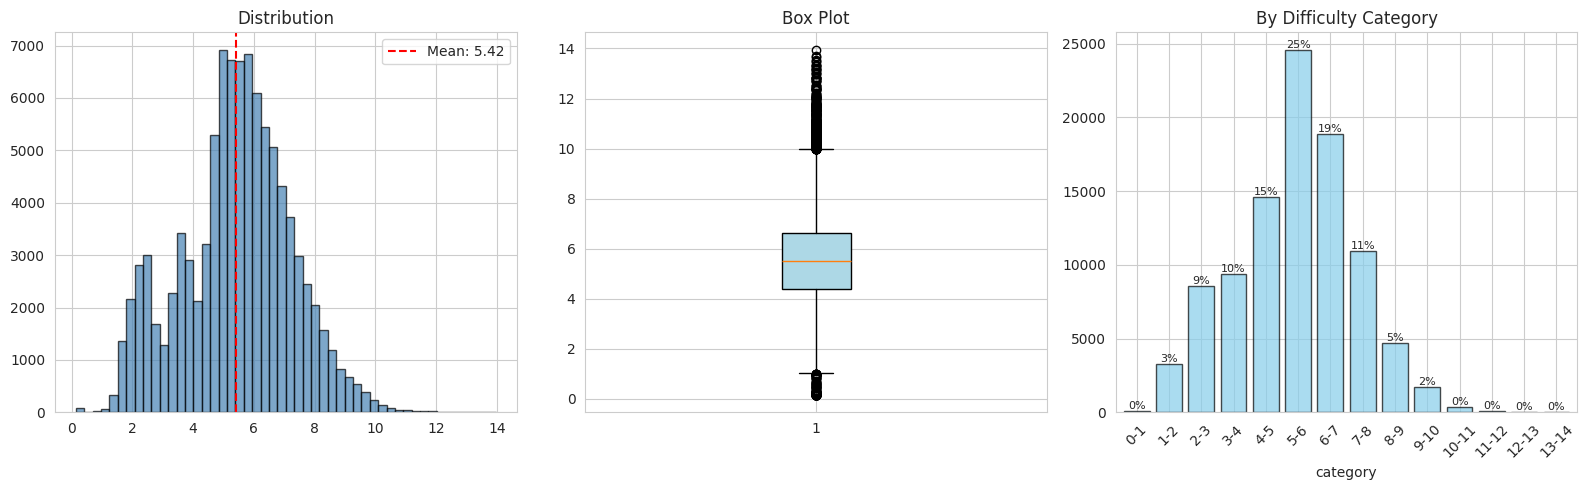

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)

ratings_df = pd.read_parquet(RATINGS_PATH)

star_df = ratings_df[['beatmap_id', 'stars']].copy()
star_df = star_df[star_df['stars'] < 14]

print(f"Loaded {len(star_df):,} beatmaps (< 14 stars)")

stats = star_df['stars'].describe()
print("\nSTAR RATING STATISTICS")
print(f"Mean:    {stats['mean']:.2f}")
print(f"Median:  {stats['50%']:.2f}")
print(f"Std Dev: {stats['std']:.2f}")
print(f"Range:   {stats['min']:.2f} - {stats['max']:.2f}")

bins = range(0, 15)
labels = [f"{i}-{i+1}" for i in range(0, 14)]
star_df['category'] = pd.cut(star_df['stars'], bins=bins, labels=labels, right=False)
cat_counts = star_df['category'].value_counts().sort_index()

print("\nDISTRIBUTION")
for label, count in cat_counts.items():
    pct = count / len(star_df) * 100
    print(f"{label:8}: {count:7,} ({pct:5.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(star_df['stars'], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(stats['mean'], color='red', linestyle='--', label=f"Mean: {stats['mean']:.2f}")
axes[0].set_title('Distribution')
axes[0].legend()

axes[1].boxplot(star_df['stars'], vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Box Plot')

cat_counts.plot(kind='bar', ax=axes[2], color='skyblue', alpha=0.7, edgecolor='black', width=0.8)
axes[2].set_title('By Difficulty Category')
axes[2].tick_params(axis='x', rotation=45)

for i, v in enumerate(cat_counts):
    axes[2].text(i, v, f'{v/len(star_df)*100:.0f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [16]:
BEATMAP_TOPIC_WEIGHTS_PATH = COLLECTIONS_DIR / "beatmap_topic_weights.parquet"
COLLECTION_TOPIC_WEIGHTS_PATH = COLLECTIONS_DIR / "collection_topic_weights.parquet"

--- 1. Loading and Pivoting Data ---
Loading beatmaps from /home/jessiez/projects/osu_corpora/data/collections/beatmap_topic_weights.parquet...
Loading collections from /home/jessiez/projects/osu_corpora/data/collections/collection_topic_weights.parquet...
Model Shape: 195759 Maps, 11485 Collections, 128 Topics

--- 2. Model Grading & Metrics ---
Beatmap Sparsity:      91.54%
Avg Topic Correlation: 0.0145 (Lower is better, closer to 0 = orthogonal topics)
Avg Classification Confidence: 0.4635 (Higher is better, max 1.0)

--- 3. Generating Visualizations ---
Running UMAP on 5000 beatmaps...


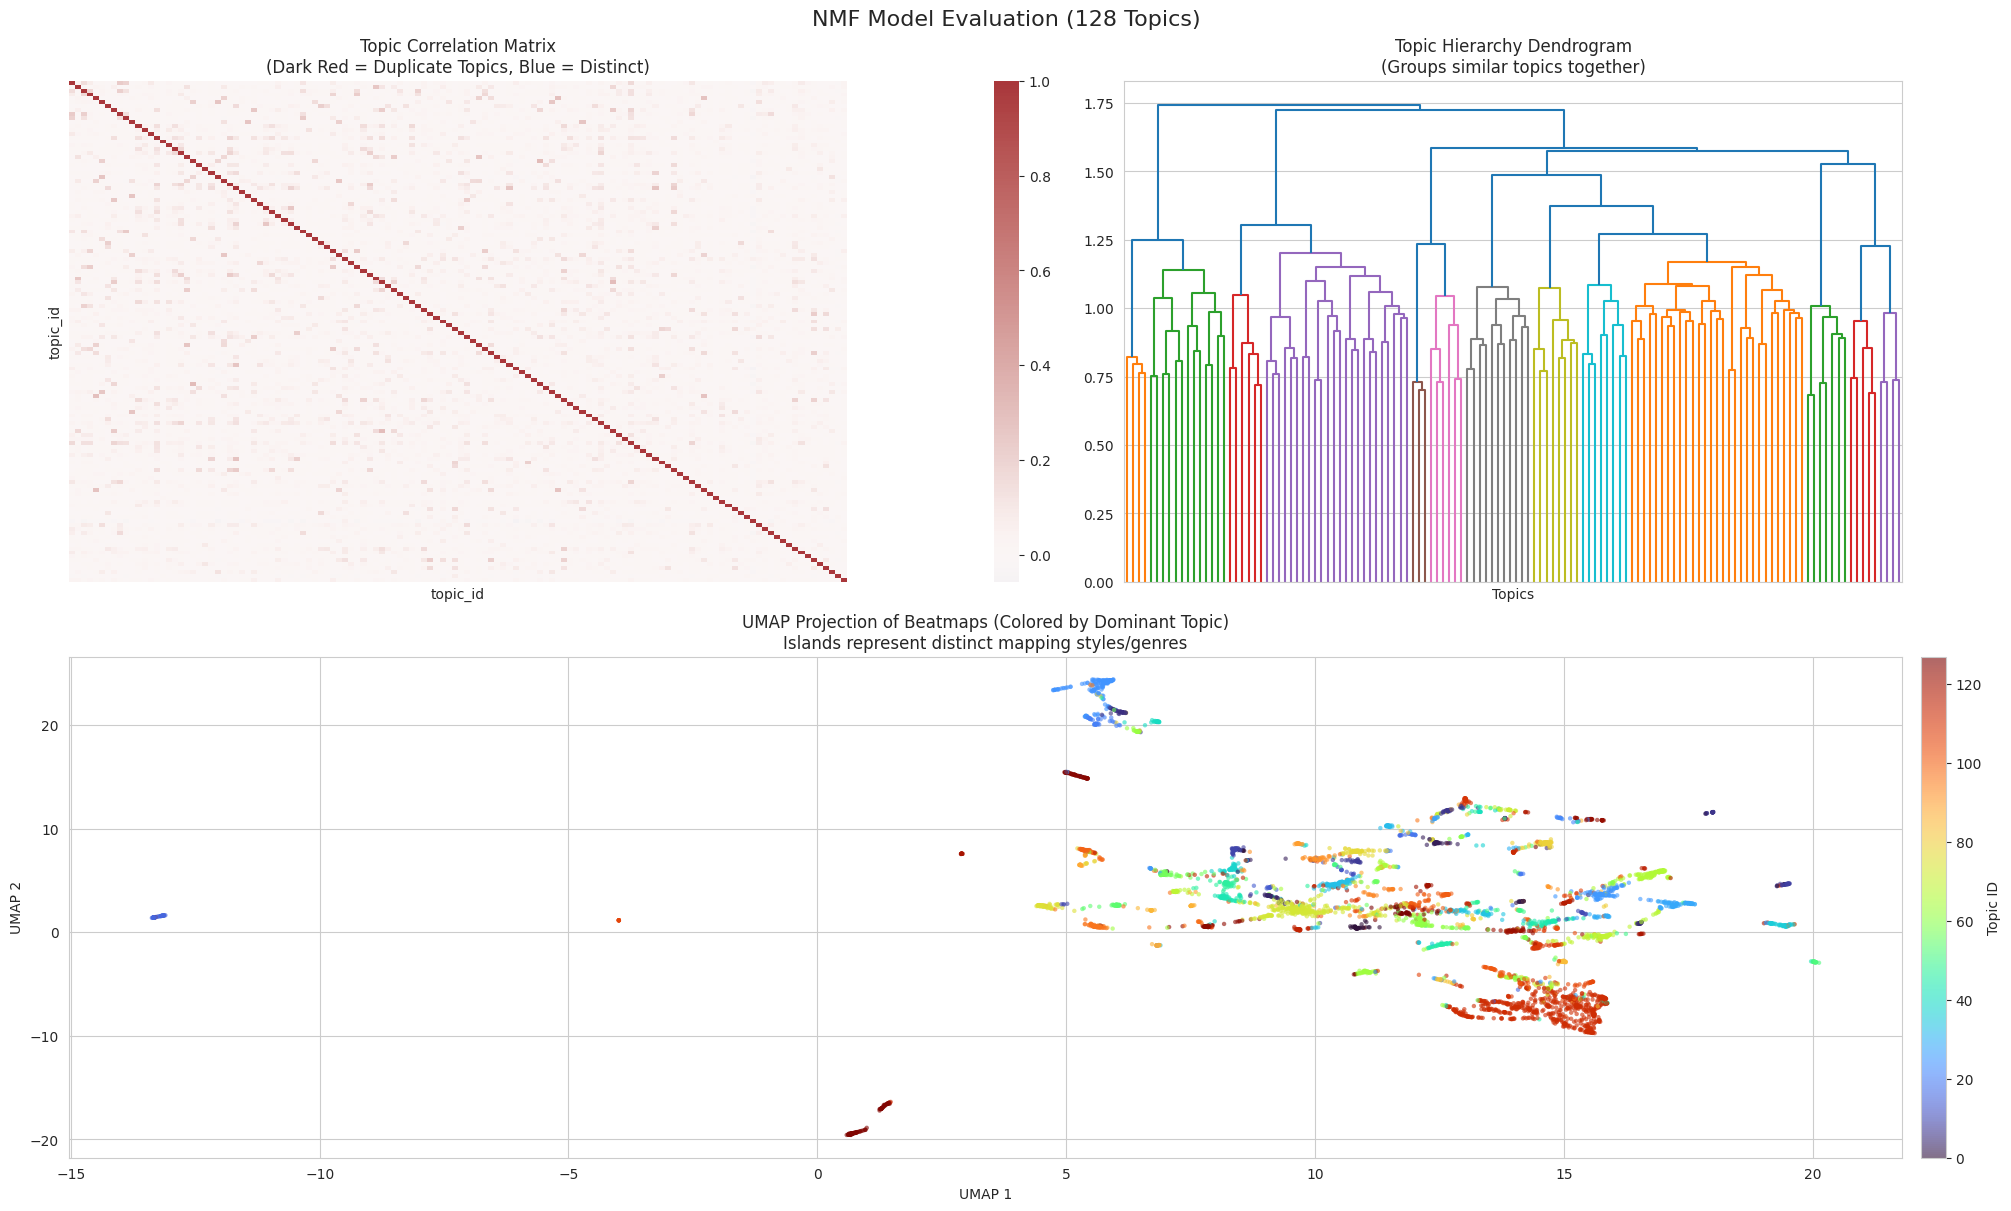

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
import umap
from sklearn.preprocessing import normalize
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

def evaluate_nmf_model(beatmap_weights_path, collection_weights_path, sample_size=5000):
    print("--- 1. Loading and Pivoting Data ---")
    
    # Load Beatmap Weights (H matrix transposed)
    df_b = pd.read_parquet(beatmap_weights_path)
    # Pivot to Dense Matrix: Rows=Beatmaps, Cols=Topics
    # Using a subset if data is massive to save RAM, but usually Osu data fits in memory
    print(f"Loading beatmaps from {beatmap_weights_path}...")
    H_T = df_b.pivot(index='beatmap_id', columns='topic_id', values='weight').fillna(0.0)
    
    # Load Collection Weights (W matrix)
    df_c = pd.read_parquet(collection_weights_path)
    print(f"Loading collections from {collection_weights_path}...")
    W = df_c.pivot(index='collection_id', columns='topic_id', values='weight').fillna(0.0)
    
    n_topics = H_T.shape[1]
    print(f"Model Shape: {H_T.shape[0]} Maps, {W.shape[0]} Collections, {n_topics} Topics")

    # --- 2. Statistical "Grading" ---
    print("\n--- 2. Model Grading & Metrics ---")
    
    # Metric A: Sparsity (Higher is usually better for NMF - means specific topics)
    sparsity_b = (H_T == 0).sum().sum() / H_T.size
    print(f"Beatmap Sparsity:      {sparsity_b:.2%}")
    
    # Metric B: Topic Exclusivity (Correlation)
    # We want topics to be distinct. Low correlation between topic columns is GOOD.
    # Calculate correlation matrix of the topics based on beatmap distributions
    topic_corr = H_T.corr()
    avg_corr = (topic_corr.values.sum() - n_topics) / (n_topics * (n_topics - 1)) # Avg off-diagonal
    print(f"Avg Topic Correlation: {avg_corr:.4f} (Lower is better, closer to 0 = orthogonal topics)")
    
    # Metric C: Confidence (Entropy approximation)
    # Do maps belong strongly to one topic, or weakly to many?
    # We normalize rows to sum to 1, then take max. Higher max = higher confidence.
    H_norm = normalize(H_T, norm='l1', axis=1)
    avg_confidence = np.mean(np.max(H_norm, axis=1))
    print(f"Avg Classification Confidence: {avg_confidence:.4f} (Higher is better, max 1.0)")

    # --- 3. Visualizations ---
    print("\n--- 3. Generating Visualizations ---")
    fig = plt.figure(figsize=(20, 12), constrained_layout=True)
    gs = fig.add_gridspec(2, 2)

    # Chart 1: Topic Correlation Matrix (Hierarchical Clustering)
    # This answers: "Which topics are similar?"
    ax1 = fig.add_subplot(gs[0, 0])
    sns.heatmap(topic_corr, cmap='vlag', center=0, ax=ax1, 
                xticklabels=False, yticklabels=False)
    ax1.set_title(f"Topic Correlation Matrix\n(Dark Red = Duplicate Topics, Blue = Distinct)")

    # Chart 2: Topic Hierarchy (Dendrogram)
    # This groups topics into meta-categories
    ax2 = fig.add_subplot(gs[0, 1])
    # Calculate distance between topics based on correlation
    dist_matrix = 1 - topic_corr # convert correlation to distance
    # linkage requires a condensed distance matrix
    # Clean NaNs if any topics are dead (all zeros)
    dist_matrix = dist_matrix.fillna(2) 
    # Extract upper triangle for hierarchy
    condensed_dist = squareform(dist_matrix.clip(lower=0), checks=False)
    Z = linkage(condensed_dist, method='ward')
    dendrogram(Z, no_labels=True, ax=ax2, color_threshold=np.max(Z[:,2])*0.7)
    ax2.set_title("Topic Hierarchy Dendrogram\n(Groups similar topics together)")
    ax2.set_xlabel("Topics")

    # Chart 3: UMAP Projection of Beatmaps
    # This visualizes the manifold. Are there distinct islands?
    ax3 = fig.add_subplot(gs[1, :])
    
    # Sample data for UMAP speed (NMF weights are features)
    if len(H_T) > sample_size:
        sample_indices = np.random.choice(H_T.index, sample_size, replace=False)
        X_sample = H_T.loc[sample_indices]
    else:
        X_sample = H_T
        
    print(f"Running UMAP on {len(X_sample)} beatmaps...")
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
    embedding = reducer.fit_transform(X_sample)
    
    # Color by dominant topic
    dominant_topic = X_sample.idxmax(axis=1)
    
    scatter = ax3.scatter(
        embedding[:, 0], 
        embedding[:, 1], 
        c=dominant_topic, 
        cmap='turbo', 
        s=10, 
        alpha=0.6,
        edgecolors='none'
    )
    ax3.set_title(f"UMAP Projection of Beatmaps (Colored by Dominant Topic)\nIslands represent distinct mapping styles/genres")
    ax3.set_xlabel("UMAP 1")
    ax3.set_ylabel("UMAP 2")
    plt.colorbar(scatter, ax=ax3, label="Topic ID", fraction=0.02, pad=0.01)

    plt.suptitle(f"NMF Model Evaluation ({n_topics} Topics)", fontsize=16)
    plt.show()

    return topic_corr, H_T

# --- Execute ---
# Ensure the variables from your prompt exist or point to actual files
if 'BEATMAP_TOPIC_WEIGHTS_PATH' in locals() and 'COLLECTION_TOPIC_WEIGHTS_PATH' in locals():
    # Verify files exist before running
    if BEATMAP_TOPIC_WEIGHTS_PATH.exists() and COLLECTION_TOPIC_WEIGHTS_PATH.exists():
        corr_matrix, beatmap_matrix = evaluate_nmf_model(
            BEATMAP_TOPIC_WEIGHTS_PATH, 
            COLLECTION_TOPIC_WEIGHTS_PATH
        )
    else:
        print("Error: Files not found at specified paths.")
else:
    print("Please define BEATMAP_TOPIC_WEIGHTS_PATH and COLLECTION_TOPIC_WEIGHTS_PATH.")